In [1]:
import matplotlib.pyplot as plt
from PIL import Image

def show_results(results):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    i = 1
    for ax, r in zip(axes, results):
        img = Image.open(r["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"Rank: {i}")
        i += 1
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [7]:
from pathlib import Path
from R2 import FashionEmbedder, FashionSearchEngine

INDEX_PATH = "vdb/R2.bin"
embedder = FashionEmbedder()
search_engine = FashionSearchEngine(embedder=embedder)

try:
    search_engine.load(INDEX_PATH)
    print("Loaded existing index.")
except Exception as e:
    print(f"Could not load index ({e}). Building a new one...")
    dataset_dir = Path("dataset/images")
    image_paths = sorted(
        p for p in dataset_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )

    search_engine.build_index(image_paths)
    Path(INDEX_PATH).parent.mkdir(parents=True, exist_ok=True)
    search_engine.save(INDEX_PATH)

Using device: mps


Loading weights: 100%|██████████| 472/472 [00:00<00:00, 67380.67it/s]


Loaded 3200 indexed images.
Loaded existing index.


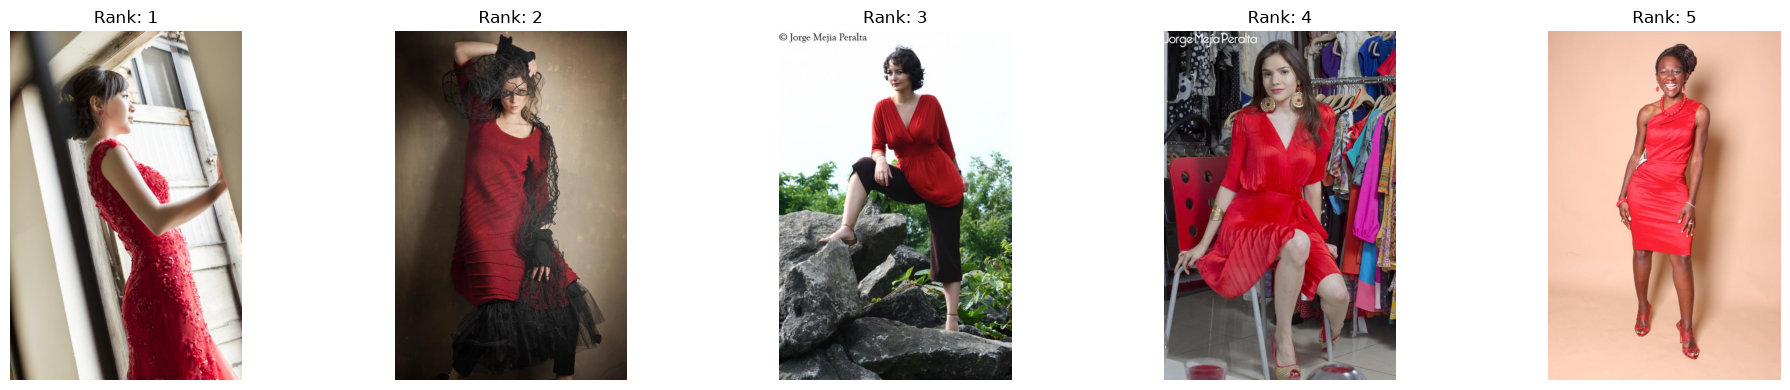

In [8]:
results = search_engine.query("vintage red dress", k_initial=30, k_final=5)
show_results(results)

In [2]:
from pathlib import Path
from MultiHead import FashionCLIPModel, VectorIndex, FashionSearchEngine

DATASET_DIR = Path("dataset/images")
INDEX_PATH = Path("models/multi_retriever.bin")

model = FashionCLIPModel()
index = VectorIndex()

image_embeddings = index.load(INDEX_PATH)

if image_embeddings is None:
    image_embeddings = index.build_from_dir(
        DATASET_DIR,
        model_handler=model,
        batch_size=32,
    )
    index.save(INDEX_PATH, image_embeddings)

search = FashionSearchEngine(
    index=index,
    model_handler=model,
)

/Users/armaanjagirdar/glance_task/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: MPS


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8422.00it/s]


No local index found. Making one


Extracting visual features: 100%|██████████| 100/100 [00:30<00:00,  3.27it/s]


In [3]:
import json

with open("dataset/instances_attributes_val2020.json", "r") as f:
    data = json.load(f)

category_labels = [c["name"].strip().lower() for c in data["categories"]]
attribute_labels = [a["name"].strip().lower() for a in data["attributes"]]

style_labels = [
    "formal",
    "casual",
    "business",
    "streetwear",
    "minimalist",
    "vintage",
    "sporty",
    "bohemian",
    "luxury",
    "preppy",
    "smart casual",
    "party wear",
]

search.set_semantic_heads(
    category_labels,
    attribute_labels,
    style_labels,
)

In [6]:
query = "A classic windbreaker with a regular fit and set-in sleeves, featuring a crew neck and slash pockets. The item is above the hip in length and has a plain design with a zip-up opening."
results = search.retrieve(
    query=query,
    image_embeddings=image_embeddings,
    k=5,
    rerank_k=50,
)

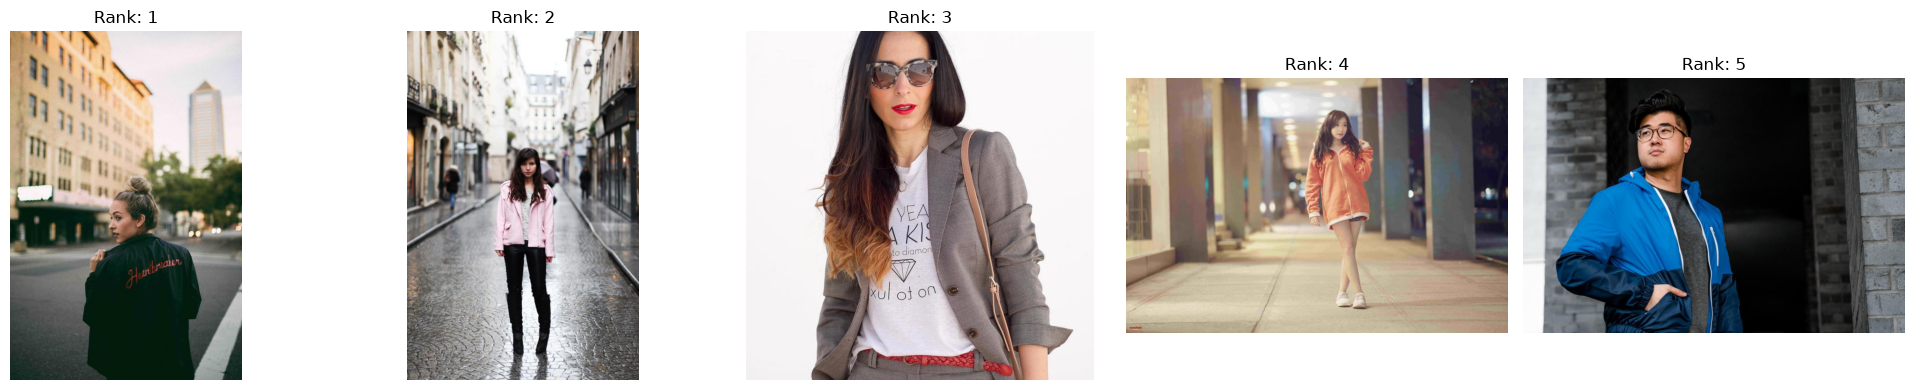

In [7]:
show_results(results)